## This is a method that given any classifier that trains on a latent in an image model to predict some attributes, in our case are ethnic groups and then it is used to debias by evenining the likelihood that the image belongs to any class.

In [1]:
#import statements
import os
os.chdir("..")
from pathlib import Path
from typing import List, Dict, Optional, Union
from t2Interp.T2I import T2IModel
from t2Interp.intervention import EncoderAttentionIntervention, ScalingAttentionIntervention #, InterventionRunner
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import seaborn

In [2]:
#Here's the classifier 
class K_Steering:
    def __init__(self, input_dim, num_classes=6, hidden_dim=256, lr=1e-3, device='cuda'):
        """
        Parameters:
          - input_dim: dimensionality of your raw activations.
          - num_classes: number of tone classes to classify.
          - hidden_dim: size of the hidden layer in the MLP.
          - lr: learning rate for training the classifier.
          - device: 'cuda' or 'cpu'.
        """
        self.device = device
        self.num_classes = num_classes
        
        # Define a multi-class MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)  # outputs logits for each tone class
        ).to(device)
        
        self.optimizer = optim.Adam(self.classifier.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Store class names for reference
        self.class_names = None
        

    def fit(self, activations_dict, epochs=30, batch_size=32, class_weights=None):
        """
        Train the multiclass classifier on raw activations.

        Parameters:
          - activations_dict: Dictionary mapping class names to NumPy arrays of activations.
          - epochs: number of training epochs.
          - batch_size: training batch size.
          - class_weights: Optional tensor of weights for each class to handle imbalance.
        """
        self.class_names = list(activations_dict.keys())
        assert len(self.class_names) == self.num_classes, f"Expected {self.num_classes} classes, got {len(self.class_names)}"
        
        # Prepare training data
        X_list = []
        y_list = []
        
        for i, class_name in enumerate(self.class_names):
            X_class = torch.tensor(activations_dict[class_name], dtype=torch.float32, device=self.device)
            y_class = torch.full((X_class.size(0),), i, dtype=torch.long, device=self.device)
            X_list.append(X_class)
            y_list.append(y_class)
        
        X = torch.cat(X_list, dim=0)
        y = torch.cat(y_list, dim=0)
        
        dataset = torch.utils.data.TensorDataset(X, y)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # Set class weights for loss function if provided
        if class_weights is not None:
            self.loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(self.device))
        
        # Train the classifier
        for epoch in range(epochs):
            self.classifier.train()
            epoch_loss = 0.0
            correct = 0
            total = 0
            
            for batch_X, batch_y in loader:
                self.optimizer.zero_grad()
                logits = self.classifier(batch_X)  # shape: (batch, num_classes)
                loss = self.loss_fn(logits, batch_y)
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = torch.max(logits.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
            
            accuracy = 100 * correct / total
            print(f"Epoch {epoch}: loss = {epoch_loss/len(loader):.4f}, accuracy = {accuracy:.2f}%")
            
        # Evaluate on each class
        self.classifier.eval()
        class_accuracies = {}
        
        with torch.no_grad():
            for i, class_name in enumerate(self.class_names):
                X_class = torch.tensor(activations_dict[class_name], dtype=torch.float32, device=self.device)
                y_class = torch.full((X_class.size(0),), i, dtype=torch.long, device=self.device)
                
                logits = self.classifier(X_class)
                _, predicted = torch.max(logits.data, 1)
                accuracy = 100 * (predicted == y_class).sum().item() / y_class.size(0)
                class_accuracies[class_name] = accuracy
                print(f"Accuracy for {class_name}: {accuracy:.2f}%")

    def steer_attributes(self, activation, target=None, avoid=None, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation toward target tones and away from tones to avoid.
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - target_tones: list of tone names to steer toward.
        - avoid_tones: list of tone names to steer away from.
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """
        
        # Validate input tone names
        if target:
            for tone in target:
                assert tone in self.class_names, f"Unknown target tone: {tone}"
        
        if avoid:
            for tone in avoid:
                assert tone in self.class_names, f"Unknown avoid tone: {tone}"
        
        # Get indices for target and avoid tones
        target_indices = [self.class_names.index(tone) for tone in target] if target else []
        avoid_indices = [self.class_names.index(tone) for tone in avoid] if avoid else []
        
        # If a single activation vector is passed, add a batch dimension
        single_input = False
        if activation.ndim == 1:
            activation = activation[None, :]
            single_input = True
        
        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                if single_input:
                    return activation[0]
                else:
                    return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()
        if single_input:
            return X_new_np[0]
        else:
            return X_new_np

    def steer_attributes_unsupervised(self, activation, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation, calculate the mean of the activations of all classes and steer away of those above the mean and towards those away from the mean .
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """


        # If a single activation vector is passed, add a batch dimension
        single_input = False
        if activation.ndim == 1:
            activation = activation[None, :]
            single_input = True
        
        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            mean_logits = torch.mean(logits, dim=1)

            target_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() < mean_logits]
            avoid_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() > mean_logits]
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                if single_input:
                    return activation[0]
                else:
                    return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()
        if single_input:
            return X_new_np[0]
        else:
            return X_new_np
        

## FairFace Dataset for T2I Debiasing

**⚠️ IMPORTANT: Download the dataset files from Google Drive:**

1. **Labels:** 
   - [Train Labels](https://drive.google.com/file/d/1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH/view)
   - [Validation Labels](https://drive.google.com/file/d/1wOdja-ezstMEp81tX1a-EYkFebev4h7D/view)

2. **Images:** 
   - [Padding=0.25](https://drive.google.com/file/d/1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86/view) (recommended)
   - [Padding=1.25](https://drive.google.com/file/d/1g7qNOZz9wC7OfOhcPqH1EZ5bk1UFGmlL/view) (for API testing)

3. **Extract to:** `/home/ubuntu/T2I_Interp_toolkit/FairFace/`
   - Place CSVs: `fairface_label_train.csv` and `fairface_label_val.csv` in the main directory
   - Extract images: `train/` and `val/` folders


In [3]:
def load_fairface_by_ethnicity(
    dataset_path: str,
    categories: Optional[List[str]] = None,
    max_images: Optional[int] = None,
    return_pil: bool = True
) -> Dict[str, List[Union[str, Image.Image]]]:
    """
    Load FairFace dataset organized by ethnic/racial categories.
    
    Parameters:
    -----------
    dataset_path : str
        Path to the fairface dataset root (e.g., '/path/to/fairface')
    categories : List[str], optional
        Specific categories to load. Available: ['Black', 'East_Asian', 'Indian', 
        'Latino_Hispanic', 'Middle_Eastern', 'Southeast_Asian', 'White']
    max_images : int, optional
        Maximum number of images to load per category
    return_pil : bool, optional
        If True, return PIL Images (for feeding to vision encoders). 
        If False, return file paths as strings. Default: True
    
    Returns:
    --------
    Dict[str, List[Union[str, Image.Image]]]
        Dictionary mapping category names to lists of PIL Images (if return_pil=True) 
        or image file paths (if return_pil=False)
    
    Example:
    --------
    >>> # Load as PIL Images (ready for vision encoders)
    >>> data = load_fairface_by_ethnicity('/path/to/fairface', return_pil=True)
    >>> print(f"White: {len(data['White'])} images")
    >>> print(f"First image type: {type(data['White'][0])}")  # <class 'PIL.Image.Image'>
    
    >>> # Load as paths only
    >>> data = load_fairface_by_ethnicity('/path/to/fairface', return_pil=False)
    >>> print(f"First image path: {data['White'][0]}")
    """
    
    all_categories = [
        'Black', 'East_Asian', 'Indian', 'Latino_Hispanic',
        'Middle_Eastern', 'Southeast_Asian', 'White'
    ]
    
    if categories is None:
        categories = all_categories
    
    race_path = Path(dataset_path) / "Race"
    dataset = {}
    
    for category in categories:
        category_path = race_path / category
        if not category_path.exists():
            print(f"Warning: {category} path not found at {category_path}")
            continue
        
        # Get all jpg images
        image_files = sorted(category_path.glob("*.jpg"))
        
        if max_images:
            image_files = image_files[:max_images]

        # Load images as PIL Images (RGB mode for vision encoders)
        dataset[category] = []
        for img_path in image_files:
            try:
                img = Image.open(img_path).convert('RGB')
                dataset[category].append(img)
            except Exception as e:
                print(f"Warning: Failed to load {img_path}: {e}")

        
        print(f"{category}: {len(dataset[category])} images")
    
    return dataset

def visualize_image(image, title=None, figsize=(5, 5)):
    """Display a single PIL image."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(image)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()



Black: 200 images
East_Asian: 200 images
Indian: 200 images
Latino_Hispanic: 200 images
Middle_Eastern: 200 images
Southeast_Asian: 200 images
White: 200 images
{'Black': [<PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F452140>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF6D1536EF0>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438250>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438370>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438310>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438340>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F4383D0>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F4383A0>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438430>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438400>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438790>, <PIL.Image.Image image mode=RGB size=224x224 at 0xFFF57F438580>, <PIL.Image.Image image mode=RGB size=224x224 at 

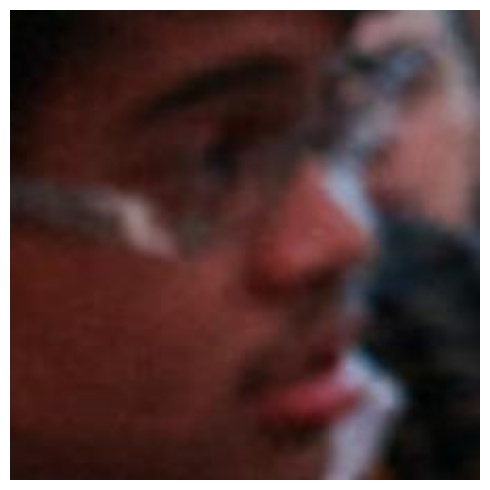

In [4]:
#Let's load the dataset
dataset_path = "/home/ubuntu/T2I_Interp_toolkit/FairFace/datasets/fairface"
data = load_fairface_by_ethnicity(dataset_path)
print(data)
visualize_image(data['Black'][0])

## Let's load in multimodal models

In [5]:
model = T2IModel("CompVis/stable-diffusion-v1-4", device="cuda:0", dtype="float16")

2025-10-13 22:23:12.916 | INFO     | t2Interp.T2I:__init__:105 - Enforcing eager attention implementation for attention pattern tracing. The HF default would be to use sdpa if available. To use sdpa, set attn_implementation='sdpa' or None to use the HF default.
Keyword arguments {'attn_implementation': 'eager', 'tokenizer_kwargs': {}, 'trust_remote_code': False} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/ubuntu/.venv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## Let's gather activations through forward hooks into the diffusion models. Note that forward hooks let us also edit models.

In [6]:
import numpy as np
import torch
from tqdm import tqdm
from torchvision import transforms

def preprocess_image_for_vae(image, target_size=512):
    """
    Preprocess PIL image for VAE encoder.
    
    Parameters:
    -----------
    image : PIL.Image
        Input image
    target_size : int
        Target size (will resize to target_size x target_size)
    
    Returns:
    --------
    torch.Tensor : Preprocessed image tensor [1, 3, H, W] in range [-1, 1]
    """
    transform = transforms.Compose([
        transforms.Resize((target_size, target_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # Scale to [-1, 1]
    ])
    return transform(image).unsqueeze(0)


def encode_images_to_latents(model, images, batch_size=8):
    """
    Encode images to latent space using VAE encoder.
    
    Parameters:
    -----------
    model : T2IModel
        The loaded T2I model
    images : List[PIL.Image] or List[torch.Tensor]
        Images to encode
    batch_size : int
        Batch size for encoding
    
    Returns:
    --------
    torch.Tensor : Latent representations [N, C, H, W]
    """
    all_latents = []
    vae = model._model.pipeline.vae
    device = next(vae.parameters()).device
    dtype = next(vae.parameters()).dtype  # Get VAE's dtype (float16 or float32)
    
    for i in range(0, len(images), batch_size):
        batch_images = images[i:i+batch_size]
        
        # Convert PIL images to tensors if needed
        if isinstance(batch_images[0], Image.Image):
            batch_tensors = torch.stack([
                preprocess_image_for_vae(img) for img in batch_images
            ]).squeeze(1)
        else:
            batch_tensors = torch.stack(batch_images)
        
        # Convert to correct device AND dtype to match VAE
        batch_tensors = batch_tensors.to(device=device, dtype=dtype)
        
        # Encode to latent space
        with torch.no_grad():
            latents = vae.encode(batch_tensors).latent_dist.sample()
            latents = latents * vae.config.scaling_factor
        
        all_latents.append(latents.cpu())
        
        # Free memory
        del batch_tensors
        torch.cuda.empty_cache()
    
    return torch.cat(all_latents, dim=0)


def batch_cache_image_activations(
    model,
    images: List[Image.Image],
    layer_name: str,
    timestep: int = 500,
    batch_size: int = 4,
    encode_batch_size: int = 8,
    aggregate_spatial: str = 'flatten',  # 'mean', 'flatten', 'none', 'last'
    empty_text_embed: bool = True,
    sequence_position: int = -1  # Position to extract for training (e.g., -1 for last)
):
    """
    Cache UNet activations from real images by encoding them and passing through UNet.
    
    This is useful for analyzing what the model "sees" in existing images,
    particularly for debiasing based on demographic attributes.
    
    Parameters:
    -----------
    model : T2IModel
        The loaded T2I model (e.g., Stable Diffusion)
    images : List[PIL.Image]
        List of PIL Images to extract activations from
    layer_name : str
        The UNet layer/module to extract activations from
        Examples:
        - "unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output"  # self-attn
        - "unet.down_blocks[0].attentions[0].transformer_blocks[0].attn2.to_out[0].output"  # cross-attn
        - "unet.mid_block.attentions[0].transformer_blocks[0].attn1.to_out[0].output"
        - "unet.down_blocks[0].resnets[0].output"  # ResNet blocks
    timestep : int
        Timestep to use for the forward pass (controls noise level)
        - Higher values (e.g., 500-999): more noise, early denoising
        - Lower values (e.g., 0-200): less noise, late denoising
    batch_size : int
        Number of images to process in each forward pass
    encode_batch_size : int
        Batch size for VAE encoding
    aggregate_spatial : str
        How to aggregate spatial dimensions:
        - 'mean': Average pool across spatial dimensions [B, C, H, W] -> [B, C]
        - 'flatten': Flatten spatial dimensions [B, C, H, W] -> [B, C*H*W]
        - 'none': Keep spatial dimensions [B, C, H, W]
    empty_text_embed : bool
        Use empty text embeddings (unconditional). Set False to use a neutral prompt.
    
    Returns:
    --------
    np.ndarray : Cached activations with shape depending on aggregate_spatial
    """
    
    print(f"Encoding {len(images)} images to latent space...")
    latents = encode_images_to_latents(model, images, batch_size=encode_batch_size)
    
    device = next(model._model.pipeline.unet.parameters()).device
    all_activations = []
    
    # Get text embeddings (empty for unconditional)
    if empty_text_embed:
        text_embeds = model._model.pipeline.encode_prompt(
            prompt="",
            device=device,
            num_images_per_prompt=1,
            do_classifier_free_guidance=False
        )[0]
    else:
        text_embeds = model._model.pipeline.encode_prompt(
            prompt="a photo",
            device=device,
            num_images_per_prompt=1,
            do_classifier_free_guidance=False
        )[0]
    
    # Create timestep tensor
    t = torch.tensor([timestep], device=device, dtype=torch.long)
    
    # Get UNet dtype
    unet_dtype = next(model._model.pipeline.unet.parameters()).dtype
    
    # Navigate to the target layer module (before any forward passes)
    # Parse the layer_name to get the actual PyTorch module
    layer_parts = layer_name.split('.')
    target_module = model._model.pipeline.unet
    
    for part in layer_parts[1:]:  # Skip 'unet' as we already have it
        if '[' in part:
            # Handle indexing like 'down_blocks[0]'
            module_name, idx = part.split('[')
            idx = int(idx.rstrip(']'))
            target_module = getattr(target_module, module_name)[idx]
        elif part == 'output':
            # 'output' is not an actual module, we want the output of the previous module
            break
        else:
            target_module = getattr(target_module, part)
    
    # Setup hook to capture activations
    activations_cache = []
    
    def hook_fn(module, input, output):
        # Store the output activation
        activations_cache.append(output.detach().cpu())
    
    # Register the hook
    handle = target_module.register_forward_hook(hook_fn)
    
    print(f"Extracting activations from layer: {layer_name}")
    try:
        for i in tqdm(range(0, len(latents), batch_size), desc="Processing batches"):
            batch_latents = latents[i:i+batch_size].to(device=device, dtype=unet_dtype)
            batch_size_actual = batch_latents.shape[0]
            
            # Expand text embeddings to match batch size
            batch_text_embeds = text_embeds.repeat(batch_size_actual, 1, 1)
            
            # Forward pass through UNet (hook will capture activation)
            with torch.no_grad():
                unet_output = model._model.pipeline.unet(
                    batch_latents,
                    t,
                    encoder_hidden_states=batch_text_embeds,
                    return_dict=False
                )
            
            # Get the captured activation
            act = activations_cache.pop(0)
            
            # Aggregate spatial dimensions if requested
            if aggregate_spatial == 'last':
                # Extract last sequence position only (like language models)
                # For [B, S, C] attention outputs
                if act.ndim == 3:
                    act = act[:, sequence_position, :]  # [B, S, C] -> [B, C]
                elif act.ndim == 4:
                    # For conv [B, C, H, W], take last spatial position
                    act = act[:, :, sequence_position, sequence_position]  # [B, C]
            elif aggregate_spatial == 'mean':
                # Average pool spatial dims
                if act.ndim == 3:
                    act = act.mean(dim=1)  # [B, S, C] -> [B, C]
                elif act.ndim == 4:
                    act = act.mean(dim=[2, 3])  # [B, C, H, W] -> [B, C]
            elif aggregate_spatial == 'flatten':
                # Flatten: [B, ...] -> [B, features]
                act = act.flatten(start_dim=1)
            # else keep as is (aggregate_spatial == 'none')
            
            all_activations.append(act.numpy())
            
            # Clear memory
            del batch_latents, batch_text_embeds, unet_output
            torch.cuda.empty_cache()
    finally:
        # Always remove the hook
        handle.remove()
    
    activations = np.concatenate(all_activations, axis=0)
    print(f"Final activation shape: {activations.shape}")
    
    return activations


def batch_cache_image_activations_by_class(
    model,
    images_dict: Dict[str, List[Image.Image]],
    layer_name: str,
    timestep: int = 500,
    batch_size: int = 4,
    encode_batch_size: int = 8,
    aggregate_spatial: str = 'flatten',
    empty_text_embed: bool = True,
    max_images_per_class: Optional[int] = None,
    sequence_position: int = -1
):
    """
    Cache UNet activations from images organized by class/category.
    
    Perfect for debiasing: extract activations from FairFace images organized by ethnicity.
    
    Parameters:
    -----------
    images_dict : Dict[str, List[PIL.Image]]
        Dictionary mapping class names to lists of images
        Example: {'Black': [img1, img2, ...], 'White': [img1, img2, ...]}
    max_images_per_class : Optional[int]
        Limit number of images per class (useful for testing)
    ... (other params same as batch_cache_image_activations)
    
    Returns:
    --------
    Dict[str, np.ndarray] : Dictionary mapping class names to activation arrays
    """
    
    activations_dict = {}
    
    for class_name, images in images_dict.items():
        # Limit images if specified
        if max_images_per_class is not None:
            images = images[:max_images_per_class]
        
        print(f"\n{'='*60}")
        print(f"Processing class: {class_name} ({len(images)} images)")
        print(f"{'='*60}")
        
        activations_dict[class_name] = batch_cache_image_activations(
            model=model,
            images=images,
            layer_name=layer_name,
            timestep=timestep,
            batch_size=batch_size,
            encode_batch_size=encode_batch_size,
            aggregate_spatial=aggregate_spatial,
            empty_text_embed=empty_text_embed,
            sequence_position=sequence_position
        )
    
    return activations_dict

In [7]:
# Train classifier on FLATTENED spatial representations
# [B, S, C] → [B, S*C] where each image is one sample with S*C features

activations_by_ethnicity = batch_cache_image_activations_by_class(
    model=model,
    images_dict=data,  # <-- Using REAL IMAGES, not prompts
    layer_name="unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output",
    timestep=500,  # Noise level for UNet forward pass
    batch_size=64,
    encode_batch_size=8,
    aggregate_spatial='flatten',  # Flatten ALL spatial: [B, S, C] → [B, S*C]
    empty_text_embed=True,  # Unconditional (no text)
    max_images_per_class=200  # Start with 20 images per ethnicity
)

print("\n✓ Training on flattened spatial representations")
print(f"✓ Each image is one sample with S*C features")
for k, v in activations_by_ethnicity.items():
    print(f"  {k}: {v.shape}")


Processing class: Black (200 images)
Encoding 200 images to latent space...
Extracting activations from layer: unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output


Processing batches: 100%|██████████| 4/4 [00:01<00:00,  2.28it/s]


Final activation shape: (200, 1310720)

Processing class: East_Asian (200 images)
Encoding 200 images to latent space...
Extracting activations from layer: unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output


Processing batches: 100%|██████████| 4/4 [00:01<00:00,  2.36it/s]


Final activation shape: (200, 1310720)

Processing class: Indian (200 images)
Encoding 200 images to latent space...
Extracting activations from layer: unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output


...

Final activation shape: (200, 1310720)

Processing class: Southeast_Asian (200 images)
Encoding 200 images to latent space...
Extracting activations from layer: unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output


Processing batches: 100%|██████████| 4/4 [00:01<00:00,  2.37it/s]


Final activation shape: (200, 1310720)

Processing class: White (200 images)
Encoding 200 images to latent space...
Extracting activations from layer: unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output


Processing batches: 100%|██████████| 4/4 [00:01<00:00,  2.34it/s]

Final activation shape: (200, 1310720)

✓ Training on flattened spatial representations
✓ Each image is one sample with S*C features
  Black: (200, 1310720)
  East_Asian: (200, 1310720)
  Indian: (200, 1310720)
  Latino_Hispanic: (200, 1310720)
  Middle_Eastern: (200, 1310720)
  Southeast_Asian: (200, 1310720)
  White: (200, 1310720)


In [8]:
# Train classifier on cached activations

# Now use the cached activations to train the K_Steering classifier
input_dim = activations_by_ethnicity['Black'].shape[-1]
num_classes = len(activations_by_ethnicity)

print(f"Input dimension: {input_dim}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(activations_by_ethnicity.keys())}")

# Initialize and train the classifier
classifier = K_Steering(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    lr=1e-3,
    device='cuda'
)

# Train on the cached activations
classifier.fit(
    activations_dict=activations_by_ethnicity,
    epochs=100,
    batch_size=32
)

print("\nClassifier trained! You can now use it for debiasing.")


Input dimension: 1310720
Number of classes: 7
Classes: ['Black', 'East_Asian', 'Indian', 'Latino_Hispanic', 'Middle_Eastern', 'Southeast_Asian', 'White']
Epoch 0: loss = 35.9847, accuracy = 15.93%
Epoch 1: loss = 3.5234, accuracy = 26.86%
Epoch 2: loss = 1.9024, accuracy = 36.29%
Epoch 3: loss = 1.4164, accuracy = 47.57%
Epoch 4: loss = 1.3428, accuracy = 52.93%
Epoch 5: loss = 1.4316, accuracy = 48.14%
Epoch 6: loss = 1.0734, accuracy = 61.21%
Epoch 7: loss = 0.8734, accuracy = 69.29%
Epoch 8: loss = 0.8614, accuracy = 71.14%
Epoch 9: loss = 0.7260, accuracy = 75.50%
Epoch 10: loss = 0.7223, accuracy = 75.29%
Epoch 11: loss = 0.6580, accuracy = 77.14%
Epoch 12: loss = 0.8270, accuracy = 70.57%
Epoch 13: loss = 0.4778, accuracy = 83.93%
Epoch 14: loss = 0.5676, accuracy = 81.57%
Epoch 15: loss = 0.6290, accuracy = 79.57%
Epoch 16: loss = 0.7361, accuracy = 75.07%
Epoch 17: loss = 0.3840, accuracy = 87.21%
Epoch 18: loss = 0.2924, accuracy = 89.71%
Epoch 19: loss = 0.2201, accuracy = 92

## Here is the markdown for the flow of the gradient editin process:
- Each denoising timestep: The UNet runs to predict noise
During UNet forward pass: Your hook at attn1.to_out[0] is triggered
In the hook:
- Extract activations from that layer
- Pass through your ethnicity classifier
- Compute gradient: ∂(classifier_loss)/∂(activations)
- Steer activations using gradient direction
Continue UNet execution with steered activations

In [ ]:
# CORRECTED debias_hook - processes each spatial position independently

def debias_hook(module, input, output, alpha=1.0):
    """
    Hook that evens out ethnicity probability distribution during forward pass.
    
    Processes whole images (flattened spatial):
    1. Flatten spatial: [B, S, C] -> [B, S*C] (each image = one sample)
    2. Pass through classifier trained on flattened features
    3. Compute gradients per image
    4. Reshape back and apply steering
    """
    # Get activation shape
    act = output
    original_shape = act.shape
    
    # Classifier was trained on flattened spatial representations: [B, S*C]
    # During steering: flatten each image, get gradients, reshape back
    # Process one image at a time in the batch dimension
    
    if act.ndim == 3:
        # Attention output: [B, S, C]
        B, S, C = act.shape
        # Flatten spatial and channel dimensions per image: [B, S, C] -> [B, S*C]
        act_flattened = act.reshape(B, S * C)
            
    elif act.ndim == 4:
        # Conv output: [B, C, H, W]
        B, C, H, W = act.shape
        # Flatten spatial and channel: [B, C, H, W] -> [B, C*H*W]
        act_flattened = act.reshape(B, C * H * W)
    else:
        # 2D: already [B, features]
        B = act.shape[0]
        act_flattened = act.clone()
        if act.ndim == 3:
            S, C = act.shape[1], act.shape[2]
        elif act.ndim == 4:
            C, H, W = act.shape[1], act.shape[2], act.shape[3]
    
    # CRITICAL: Create completely independent tensor for classifier
    # Step 1: Detach from UNet computation graph
    act_detached = act_flattened.detach()
    
    # Step 2: Convert to numpy (breaks all PyTorch graph connections)
    act_np = act_detached.cpu().numpy()
    
    # Step 3: Create NEW tensor from numpy copy (completely independent)
    # This tensor has NO connection to UNet's autograd graph
    act_tensor = torch.from_numpy(act_np.copy()).to(
        device=classifier.device,
        dtype=torch.float32
    )
    
    # Step 4: EXPLICITLY enable gradients for this computation
    # The UNet forward pass may be in torch.no_grad() context, so we override it
    with torch.enable_grad():
        # Create tensor with gradients enabled
        act_tensor.requires_grad_(True)
        
        # Verify independence
        assert act_tensor.grad_fn is None, "Tensor should not have grad_fn from UNet"
        assert not act_flattened.requires_grad, "Original activations should not require grad"
        
        # Ensure classifier is in train mode for proper gradient flow
        classifier.classifier.eval()
        
        # Forward pass through classifier - each image gets prediction
        logits = classifier.classifier(act_tensor)  # [B, num_classes]
        
        # Target: uniform distribution - match K_Steering.steer_attributes_unsupervised approach
        # Separate logits into over-represented (avoid) and under-represented (target)
        
        # Get mean logit per image across all classes
        mean_logits = logits.mean(dim=1, keepdim=True)  # [B, 1]
        
        # Identify which classes are above/below mean for each image
        logits_deviation = logits - mean_logits  # [B, num_classes]
        
        # Classes above mean = over-represented (need to decrease)
        # Classes below mean = under-represented (need to increase)
        avoid_mask = logits_deviation > 0  # Over-represented
        target_mask = logits_deviation < 0  # Under-represented
        
        # Build loss to minimize over-represented and maximize under-represented
        loss = 0.0
        
        if avoid_mask.any():
            avoid_logits = logits * avoid_mask.float()
            loss = loss + avoid_logits.sum() / (avoid_mask.sum() + 1e-8)  # Minimize these
        
        if target_mask.any():
            target_logits = logits * target_mask.float()
            loss = loss - target_logits.sum() / (target_mask.sum() + 1e-8)  # Maximize these (negative)
        
        # This loss encourages all classes to move toward the mean, achieving uniformity
        
        # Compute gradients for each image (ONLY through classifier, not UNet)
        grad = torch.autograd.grad(
            outputs=loss,
            inputs=act_tensor,
            retain_graph=False,
            create_graph=False,
            only_inputs=True,
        )[0]  # [B, S*C]
        
        # Steering direction (negative gradient to minimize bias)
        steering_direction = -grad
        
        # Restore classifier to eval mode
        #classifier.classifier.eval()
    
    # Step 5: Move steering back via numpy (complete isolation from both graphs)
    steering_np = steering_direction.detach().cpu().numpy()
    
    # Step 6: Create NEW tensor on original device (no graph connections)
    steering_tensor = torch.from_numpy(steering_np.copy()).to(
        device=act_flattened.device,
        dtype=act_flattened.dtype
    )
    
    # Step 7: Apply steering - simple addition, no gradients
    steered_flat = act_flattened.detach() + alpha * steering_tensor
        

    # Reshape back to original shape
    if len(original_shape) == 3:
        # [B, S*C] -> [B, S, C]
        B, S, C = original_shape
        steered_output = steered_flat.reshape(B, S, C)
    elif len(original_shape) == 4:
        # [B, C*H*W] -> [B, C, H, W]
        B, C, H, W = original_shape
        steered_output = steered_flat.reshape(B, C, H, W)
    else:
        steered_output = steered_flat
    
    return steered_output


In [14]:
# Update analyze function to match training approach
# Ethnicity Debiasing with Activation Steering
import functools
import json
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


# Test prompts - occupation and role-based prompts where bias typically shows up
test_prompts = [
    "a photo of a doctor",
    # "a photo of a nurse", 
    # "a photo of a CEO",
    # "a photo of an engineer",
    # "a photo of a teacher",
    # "a photo of a scientist",
    # "a photo of a lawyer",
    # "a photo of an artist",
    # "a photo of a chef",
    # "a photo of a person",
]

# Settings
alphas_to_try = [1.0, 10.0, 100.0]
num_generations_per_prompt = 15
num_inference_steps = 20
batch_size = 1

# Layer for intervention (where we apply debiasing)
target_layer = "unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0]"

# Layer for analysis (where we extract features for ethnicity prediction)
# This is the layer where we are extracting features to predict ethnicity
layer_to_probe = "unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output"


In [15]:

def generate_images_with_debiasing(prompts, alpha=0.0, seed=42):
    """
    Generate images with optional debiasing intervention.
    
    Uses the pipeline directly (not nnsight trace) to avoid conflicts with hook gradients.
    
    Args:
        prompts: List of text prompts
        alpha: Steering strength (0 = no intervention, higher = stronger)
        seed: Random seed
    
    Returns:
        List of PIL Images
    """
    images = []
    
    # Get target module for hook
    layer_parts = target_layer.split('.')
    target_module = model._model.pipeline.unet
    
    for part in layer_parts[1:]:  # Skip 'unet'
        if '[' in part:
            module_name, idx = part.split('[')
            idx = int(idx.rstrip(']'))
            target_module = getattr(target_module, module_name)[idx]
        elif part == 'output':
            break
        else:
            target_module = getattr(target_module, part)
    
    # Register hook if alpha > 0
    if alpha > 0:
        hook_fn = functools.partial(debias_hook, alpha=alpha)
        handle = target_module.register_forward_hook(hook_fn)
    
    try:
        # Use pipeline directly instead of model.generate() to avoid nnsight tracing conflicts
        for prompt in tqdm(prompts, desc=f"Generating (alpha={alpha})"):
            # Set seed for reproducibility
            generator = torch.Generator(device=model._model.pipeline.device).manual_seed(seed)
            
            # Generate using pipeline directly
            output = model._model.pipeline(
                prompt=prompt,
                num_inference_steps=num_inference_steps,
                generator=generator,
                return_dict=True
            )
            
            images.append(output.images[0])
            seed += 1  # Different seed for each generation
    finally:
        if alpha > 0:
            handle.remove()
    
    return images


def analyze_ethnicity_distribution(images, batch_size=1):
    """
    Analyze ethnicity distribution in generated images using the trained classifier.
    
    Args:
        images: List of PIL Images (generated images)
        batch_size: Batch size for processing
    
    Returns:
        Dict mapping ethnicity names to their proportions
    """
    print(f"\nAnalyzing ethnicity distribution for {len(images)} images...")
    
    # Extract activations from generated images using SAME method as training
    activations = batch_cache_image_activations(
        model=model,
        images=images,
        layer_name=layer_to_probe,  # Same layer used for training
        timestep=500,
        batch_size=1,
        encode_batch_size=8,
        aggregate_spatial='flatten',  # ✓ Match training: ALL positions
        empty_text_embed=True
    )
    
    # activations shape: [num_images * num_positions, C]
    print(f"Extracted {activations.shape[0]} position activations from {len(images)} images")
    
    # Predict ethnicity for ALL positions, then aggregate per image
    classifier.classifier.eval()
    all_probs = []
    
    with torch.no_grad():
        # Process all position activations in batches
        for i in range(0, len(activations), 1024):
            batch_acts = activations[i:i+1024]
            batch_tensor = torch.tensor(batch_acts, dtype=torch.float32, device=classifier.device)
            
            # Get probabilities for each position
            logits = classifier.classifier(batch_tensor)
            probs = torch.softmax(logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
    
    # Concatenate all position probabilities: [num_images * num_positions, num_classes]
    all_probs = np.concatenate(all_probs, axis=0)
    
    # Reshape to [num_images, num_positions, num_classes]
    num_positions = all_probs.shape[0] // len(images)
    all_probs = all_probs.reshape(len(images), num_positions, classifier.num_classes)
    
    # Aggregate per image: average probabilities across all positions
    image_probs = all_probs.mean(axis=1)  # [num_images, num_classes]
    
    # Final prediction per image
    predictions = np.argmax(image_probs, axis=1)
    
    # Count predictions
    counts = np.bincount(predictions, minlength=len(classifier.class_names))
    
    # Convert to distribution
    distribution = {
        classifier.class_names[i]: counts[i] / len(images)
        for i in range(len(classifier.class_names))
    }
    
    return distribution


# Main experiment loop
results = {
    "meta": {
        "test_prompts": test_prompts,
        "num_generations_per_prompt": num_generations_per_prompt,
        "alphas_tested": alphas_to_try,
        "target_layer": target_layer,
        "ethnicity_classes": classifier.class_names
    },
    "experiments": []
}

print("\n" + "="*80)
print("BASELINE: Generating without debiasing intervention")
print("="*80)

baseline_images = generate_images_with_debiasing(
    prompts=test_prompts * num_generations_per_prompt,
    alpha=0.0,
    seed=42
)

# Analyze baseline distribution
baseline_dist = analyze_ethnicity_distribution(baseline_images)
results["baseline_distribution"] = baseline_dist

print("\nBaseline ethnicity distribution:")
for ethnicity, prob in baseline_dist.items():
    print(f"  {ethnicity}: {prob:.3f}")

# Test different alpha values
for alpha in alphas_to_try:
    print("\n" + "="*80)
    print(f"DEBIASING with alpha = {alpha}")
    print("="*80)
    
    debiased_images = generate_images_with_debiasing(
        prompts=test_prompts * num_generations_per_prompt,
        alpha=alpha,
        seed=42
    )
    
    # Analyze distribution
    debiased_dist = analyze_ethnicity_distribution(debiased_images)
    
    print(f"\nDebiased ethnicity distribution (alpha={alpha}):")
    for ethnicity, prob in debiased_dist.items():
        baseline_prob = baseline_dist[ethnicity]
        change = prob - baseline_prob
        print(f"  {ethnicity}: {prob:.3f} (Δ{change:+.3f})")
    
    # Compute uniformity metric (lower = more uniform)
    target_uniform = 1.0 / len(classifier.class_names)
    uniformity_score = sum(abs(prob - target_uniform) for prob in debiased_dist.values())
    baseline_uniformity = sum(abs(prob - target_uniform) for prob in baseline_dist.values())
    
    print(f"\nUniformity score: {uniformity_score:.4f} (baseline: {baseline_uniformity:.4f})")
    print(f"Improvement: {((baseline_uniformity - uniformity_score) / baseline_uniformity * 100):.1f}%")
    
    results["experiments"].append({
        "alpha": alpha,
        "distribution": debiased_dist,
        "uniformity_score": uniformity_score,
        "improvement_pct": (baseline_uniformity - uniformity_score) / baseline_uniformity * 100
    })

# Save results
output_path = "ethnicity_debiasing_results.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Results saved to: {output_path}")


BASELINE: Generating without debiasing intervention


Generating (alpha=0.0):   0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Generating (alpha=0.0):   7%|▋         | 1/15 [00:01<00:20,  1.49s/it]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

Generating (alpha=100.0): 100%|██████████| 15/15 [00:23<00:00,  1.56s/it]



Analyzing ethnicity distribution for 15 images...
Encoding 15 images to latent space...
Extracting activations from layer: unet.down_blocks[0].attentions[0].transformer_blocks[0].attn1.to_out[0].output


Processing batches: 100%|██████████| 15/15 [00:01<00:00, 14.08it/s]

Final activation shape: (15, 1310720)
Extracted 15 position activations from 15 images

Debiased ethnicity distribution (alpha=100.0):
  Black: 0.067 (Δ-0.067)
  East_Asian: 0.200 (Δ-0.133)
  Indian: 0.000 (Δ+0.000)
  Latino_Hispanic: 0.000 (Δ+0.000)
  Middle_Eastern: 0.067 (Δ-0.067)
  Southeast_Asian: 0.133 (Δ+0.067)
  White: 0.533 (Δ+0.200)

Uniformity score: 0.8952 (baseline: 0.7619)
Improvement: -17.5%

✓ Results saved to: ethnicity_debiasing_results.json
